In [ ]:
import shutil

# Adjust the Drive path to wherever you placed the files
DRIVE_FOLDER = "/content/drive/MyDrive/oral_disease_training"
for f in ["archive (1).zip", "archive (3).zip", "archive (6).zip",
          "densenet_oral_model_improved.pth", "finetune_with_new_data.py"]:
    src = f"{DRIVE_FOLDER}/{f}"
    dst = f"/content/{f}"
    print(f"Copying {f} ...")
    shutil.copy2(src, dst)
print("✅ Done!")


Copying archive (1).zip ...
Copying archive (3).zip ...
Copying archive (6).zip ...
Copying densenet_oral_model_improved.pth ...
Copying finetune_with_new_data.py ...
✅ Done!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install kagglehub huggingface_hub


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!python /content/finetune_with_new_data.py



✅ Google Drive detected! Model will be saved to your Drive.
Using device: cuda

📥 Step 1a: Download extra Kaggle & Hugging Face datasets

  📥 Downloading shivam17299/oral-cancer-lips-and-tongue-images …
Using Colab cache for faster access to the 'oral-cancer-lips-and-tongue-images' dataset.
     → /kaggle/input/oral-cancer-lips-and-tongue-images
  📥 Downloading samxengineer/augumented-oral-cancer-dataset …
Using Colab cache for faster access to the 'augumented-oral-cancer-dataset' dataset.
     → /kaggle/input/augumented-oral-cancer-dataset
  📥 Downloading obulisainaren/multi-cancer …
Using Colab cache for faster access to the 'multi-cancer' dataset.
     → /kaggle/input/multi-cancer
  🤗 Downloading HRruiH/Dataset-of-oral-mucosal-diseases from Hugging Face …
Fetching 3 files:   0% 0/3 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
Fetching 3 files: 100% 3/3 [00:09<00:00,  3.24s/i


✅ Google Drive detected! Model will be saved to your Drive.
Using device: cuda
Rebuilding model architecture...
Loading saved model from Google Drive...
Rebuilding Test Data Loader...
Running evaluation on Test Set...

🎯 FINAL TEST ACCURACY: 95.61%

                     precision    recall  f1-score   support

           Calculus     0.7006    0.8462    0.7666       130
             Caries     0.9846    0.9770    0.9808       261
         Gingivitis     0.8732    0.7915    0.8304       235
         Hypodontia     0.9921    1.0000    0.9960       126
         Non Cancer     1.0000    0.9503    0.9745      1046
        Oral Cancer     0.9526    0.9857    0.9688       978
Tooth Discoloration     0.9901    0.9901    0.9901       202
             Ulcers     0.9525    1.0000    0.9757       281

           accuracy                         0.9561      3259
          macro avg     0.9307    0.9426    0.9354      3259
       weighted avg     0.9584    0.9561    0.9565      3259



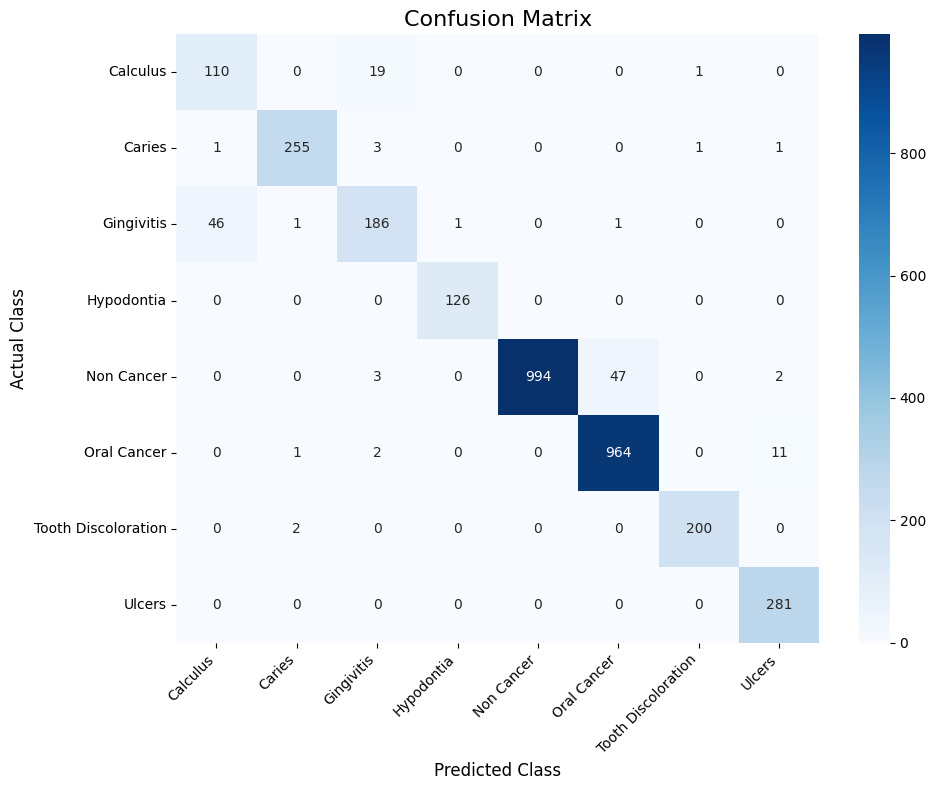

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import classification_report, confusion_matrix
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

# Import the architecture and variables from your python script
import finetune_with_new_data as fnd

print("Rebuilding model architecture...")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the 8-class model structure
model = fnd.CustomDenseNet(num_classes=8)
model = model.to(DEVICE)

print("Loading saved model from Google Drive...")
model.load_state_dict(torch.load("/content/drive/MyDrive/densenet_oral_model_finetuned.pth", map_location=DEVICE))
model.eval()

print("Rebuilding Test Data Loader...")
test_dir = os.path.join(fnd.WORK_DIR, "test")
test_dataset = ImageFolder(test_dir, transform=fnd.val_transforms, loader=fnd.safe_pil_loader)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

all_preds, all_labels = [], []

print("Running evaluation on Test Set...")
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
class_names = test_dataset.classes

print(f"\n🎯 FINAL TEST ACCURACY: {test_accuracy * 100:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# Draw the Confusion Matrix Graphic
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


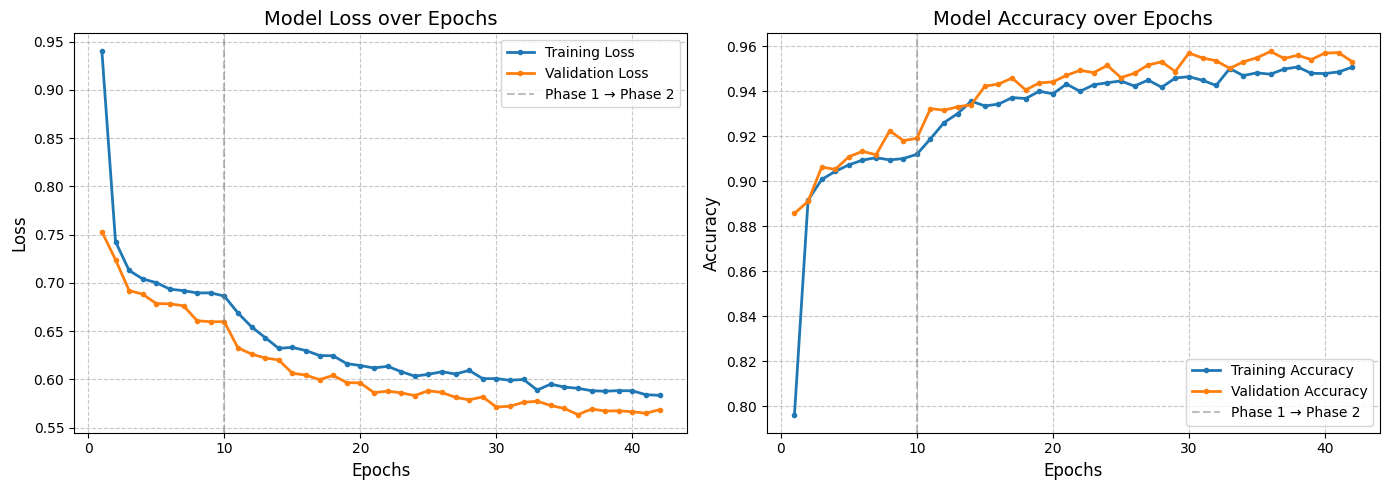

✅ Graph saved to Google Drive as training_curves.png


In [ ]:
import re
import matplotlib.pyplot as plt

log_text = """
  Epoch [1/10]  Train Loss: 0.9397  Train Acc: 0.7963  Val Loss: 0.7529  Val Acc: 0.8857
  Epoch [2/10]  Train Loss: 0.7427  Train Acc: 0.8916  Val Loss: 0.7240  Val Acc: 0.8911
  Epoch [3/10]  Train Loss: 0.7128  Train Acc: 0.9008  Val Loss: 0.6920  Val Acc: 0.9063
  Epoch [4/10]  Train Loss: 0.7040  Train Acc: 0.9044  Val Loss: 0.6882  Val Acc: 0.9053
  Epoch [5/10]  Train Loss: 0.7002  Train Acc: 0.9073  Val Loss: 0.6785  Val Acc: 0.9109
  Epoch [6/10]  Train Loss: 0.6934  Train Acc: 0.9094  Val Loss: 0.6782  Val Acc: 0.9133
  Epoch [7/10]  Train Loss: 0.6919  Train Acc: 0.9105  Val Loss: 0.6762  Val Acc: 0.9118
  Epoch [8/10]  Train Loss: 0.6895  Train Acc: 0.9095  Val Loss: 0.6607  Val Acc: 0.9225
  Epoch [9/10]  Train Loss: 0.6896  Train Acc: 0.9101  Val Loss: 0.6597  Val Acc: 0.9181
  Epoch [10/10]  Train Loss: 0.6863  Train Acc: 0.9120  Val Loss: 0.6597  Val Acc: 0.9191
  Epoch [1/50]  Train Loss: 0.6688  Train Acc: 0.9189  Val Loss: 0.6326  Val Acc: 0.9323
  Epoch [2/50]  Train Loss: 0.6544  Train Acc: 0.9261  Val Loss: 0.6262  Val Acc: 0.9316
  Epoch [3/50]  Train Loss: 0.6433  Train Acc: 0.9301  Val Loss: 0.6221  Val Acc: 0.9331
  Epoch [4/50]  Train Loss: 0.6321  Train Acc: 0.9356  Val Loss: 0.6201  Val Acc: 0.9340
  Epoch [5/50]  Train Loss: 0.6331  Train Acc: 0.9335  Val Loss: 0.6063  Val Acc: 0.9423
  Epoch [6/50]  Train Loss: 0.6298  Train Acc: 0.9343  Val Loss: 0.6044  Val Acc: 0.9432
  Epoch [7/50]  Train Loss: 0.6247  Train Acc: 0.9372  Val Loss: 0.5997  Val Acc: 0.9459
  Epoch [8/50]  Train Loss: 0.6244  Train Acc: 0.9368  Val Loss: 0.6041  Val Acc: 0.9406
  Epoch [9/50]  Train Loss: 0.6163  Train Acc: 0.9400  Val Loss: 0.5966  Val Acc: 0.9437
  Epoch [10/50]  Train Loss: 0.6143  Train Acc: 0.9389  Val Loss: 0.5963  Val Acc: 0.9442
  Epoch [11/50]  Train Loss: 0.6118  Train Acc: 0.9432  Val Loss: 0.5862  Val Acc: 0.9471
  Epoch [12/50]  Train Loss: 0.6135  Train Acc: 0.9400  Val Loss: 0.5878  Val Acc: 0.9493
  Epoch [13/50]  Train Loss: 0.6080  Train Acc: 0.9429  Val Loss: 0.5860  Val Acc: 0.9483
  Epoch [14/50]  Train Loss: 0.6033  Train Acc: 0.9438  Val Loss: 0.5832  Val Acc: 0.9515
  Epoch [15/50]  Train Loss: 0.6052  Train Acc: 0.9446  Val Loss: 0.5882  Val Acc: 0.9461
  Epoch [16/50]  Train Loss: 0.6079  Train Acc: 0.9423  Val Loss: 0.5864  Val Acc: 0.9480
  Epoch [17/50]  Train Loss: 0.6055  Train Acc: 0.9450  Val Loss: 0.5813  Val Acc: 0.9517
  Epoch [18/50]  Train Loss: 0.6093  Train Acc: 0.9418  Val Loss: 0.5788  Val Acc: 0.9531
  Epoch [19/50]  Train Loss: 0.6007  Train Acc: 0.9459  Val Loss: 0.5818  Val Acc: 0.9488
  Epoch [20/50]  Train Loss: 0.6008  Train Acc: 0.9465  Val Loss: 0.5713  Val Acc: 0.9570
  Epoch [21/50]  Train Loss: 0.5990  Train Acc: 0.9449  Val Loss: 0.5721  Val Acc: 0.9548
  Epoch [22/50]  Train Loss: 0.5999  Train Acc: 0.9426  Val Loss: 0.5762  Val Acc: 0.9536
  Epoch [23/50]  Train Loss: 0.5889  Train Acc: 0.9501  Val Loss: 0.5773  Val Acc: 0.9502
  Epoch [24/50]  Train Loss: 0.5950  Train Acc: 0.9470  Val Loss: 0.5729  Val Acc: 0.9531
  Epoch [25/50]  Train Loss: 0.5920  Train Acc: 0.9482  Val Loss: 0.5698  Val Acc: 0.9549
  Epoch [26/50]  Train Loss: 0.5907  Train Acc: 0.9476  Val Loss: 0.5635  Val Acc: 0.9577
  Epoch [27/50]  Train Loss: 0.5882  Train Acc: 0.9499  Val Loss: 0.5692  Val Acc: 0.9546
  Epoch [28/50]  Train Loss: 0.5877  Train Acc: 0.9508  Val Loss: 0.5672  Val Acc: 0.9560
  Epoch [29/50]  Train Loss: 0.5883  Train Acc: 0.9480  Val Loss: 0.5674  Val Acc: 0.9541
  Epoch [30/50]  Train Loss: 0.5881  Train Acc: 0.9479  Val Loss: 0.5664  Val Acc: 0.9570
  Epoch [31/50]  Train Loss: 0.5841  Train Acc: 0.9486  Val Loss: 0.5649  Val Acc: 0.9572
  Epoch [32/50]  Train Loss: 0.5834  Train Acc: 0.9507  Val Loss: 0.5686  Val Acc: 0.9532
"""

train_loss = [float(x) for x in re.findall(r'Train Loss:\s+([\d\.]+)', log_text)]
train_acc = [float(x) for x in re.findall(r'Train Acc:\s+([\d\.]+)', log_text)]
val_loss = [float(x) for x in re.findall(r'Val Loss:\s+([\d\.]+)', log_text)]
val_acc = [float(x) for x in re.findall(r'Val Acc:\s+([\d\.]+)', log_text)]

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss', marker='o', markersize=3, linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', marker='o', markersize=3, linewidth=2)
plt.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='Phase 1 → Phase 2')
plt.title('Model Loss over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label='Training Accuracy', marker='o', markersize=3, linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o', markersize=3, linewidth=2)
plt.axvline(x=10, color='gray', linestyle='--', alpha=0.5, label='Phase 1 → Phase 2')
plt.title('Model Accuracy over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/training_curves.png", dpi=150)
plt.show()
print("✅ Graph saved to Google Drive as training_curves.png")
